### 전처리

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, kruskal, f_oneway
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.unicode_minus'] = False

In [51]:
df = pd.read_csv("최종(질병제외).csv")
print(list(df.columns))

['key', 'name', 'u_geoid', 'lst_summer', 'lst_summer_m', 'ndvi_summer', 'ndvi_summer_m', 'uhi_day', 'uhi_summer_day', 'holc', 'poverty_p', 'uninsured_rate', 'plumbing_lack_rate', 'A_Score', 'A_Ratio', 'A_Density', 'V_Density', 'limited_english_rate', 'renter_rate', 'low_education_rate', 'before1970_rate', 'year_mean', 'overcrowd_all', 'overcrowd_own', 'overcrowd_rent', 'own_rate']


In [3]:
# poverty_p
df['poverty_p'] = pd.to_numeric(df['poverty_p'], errors='coerce')

# before1970_rate
df['before1970_rate'] = pd.to_numeric(df['before1970_rate'], errors='coerce')


holc_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4}
df['holc_num'] = df['holc'].map(holc_map)

df['Y'] =df['lst_summer'] - df['lst_summer_m']
df['ndvi_diff'] = df['ndvi_summer'] - df['ndvi_summer_m']

miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
miss_df = pd.DataFrame({'missing_n': miss, 'missing_%': miss_pct})
print(miss_df[miss_df['missing_n'] > 0].to_string())

                      missing_n  missing_%
lst_summer                  136        1.0
poverty_p                   274        2.0
uninsured_rate              265        2.0
plumbing_lack_rate          284        2.1
A_Score                     186        1.4
A_Ratio                     186        1.4
A_Density                   186        1.4
V_Density                   186        1.4
limited_english_rate        186        1.4
renter_rate                 186        1.4
low_education_rate          186        1.4
before1970_rate             281        2.1
year_mean                   281        2.1
overcrowd_all               284        2.1
overcrowd_own               408        3.0
overcrowd_rent              295        2.2
own_rate                    408        3.0
Y                           136        1.0


In [4]:
df_mis = df.copy().dropna()
q1_y = df_mis['Y'].quantile(0.25)
q3_y = df_mis['Y'].quantile(0.75)
iqr_y = q3_y - q1_y

lower = q1_y - 1.5 * iqr_y
upper = q3_y + 1.5 * iqr_y

df_drop = df_mis[(df_mis['Y'] >= lower) & (df_mis['Y'] <= upper)]

print(f"정제 전 데이터 개수: {len(df)}개")
print(f"정제 후 남은 데이터 개수: {len(df_drop)}개")

정제 전 데이터 개수: 13518개
정제 후 남은 데이터 개수: 12663개


In [7]:
num = df_drop.select_dtypes(include='number').copy()
numdf = num.copy()
k = ['u_geoid', 'lst_summer', 'lst_summer_m', 'ndvi_summer', 'ndvi_summer_m', 'uhi_day', 'uhi_summer_day', 'own_rate']
ind = [col for col in k if col in num.columns]
numdf = numdf.drop(columns=ind)
numdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12663 entries, 0 to 13517
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   12663 non-null  int64  
 1   poverty_p             12663 non-null  float64
 2   uninsured_rate        12663 non-null  float64
 3   plumbing_lack_rate    12663 non-null  float64
 4   A_Score               12663 non-null  float64
 5   A_Ratio               12663 non-null  float64
 6   A_Density             12663 non-null  float64
 7   V_Density             12663 non-null  float64
 8   limited_english_rate  12663 non-null  float64
 9   renter_rate           12663 non-null  float64
 10  low_education_rate    12663 non-null  float64
 11  before1970_rate       12663 non-null  float64
 12  year_mean             12663 non-null  float64
 13  overcrowd_all         12663 non-null  float64
 14  overcrowd_own         12663 non-null  float64
 15  overcrowd_rent        12

In [9]:
import pickle
with open('num.pickle', 'wb') as pickle_filename:
    pickle.dump(num, pickle_filename)

In [8]:
import pickle
with open('numdf.pickle', 'wb') as pickle_filename:
    pickle.dump(numdf, pickle_filename)

In [12]:
print(list(numdf.columns)) 

['key', 'poverty_p', 'uninsured_rate', 'plumbing_lack_rate', 'A_Score', 'A_Ratio', 'A_Density', 'V_Density', 'limited_english_rate', 'renter_rate', 'low_education_rate', 'before1970_rate', 'year_mean', 'overcrowd_all', 'overcrowd_own', 'overcrowd_rent', 'holc_num', 'Y', 'ndvi_diff']


### 기초통계 및 시각화

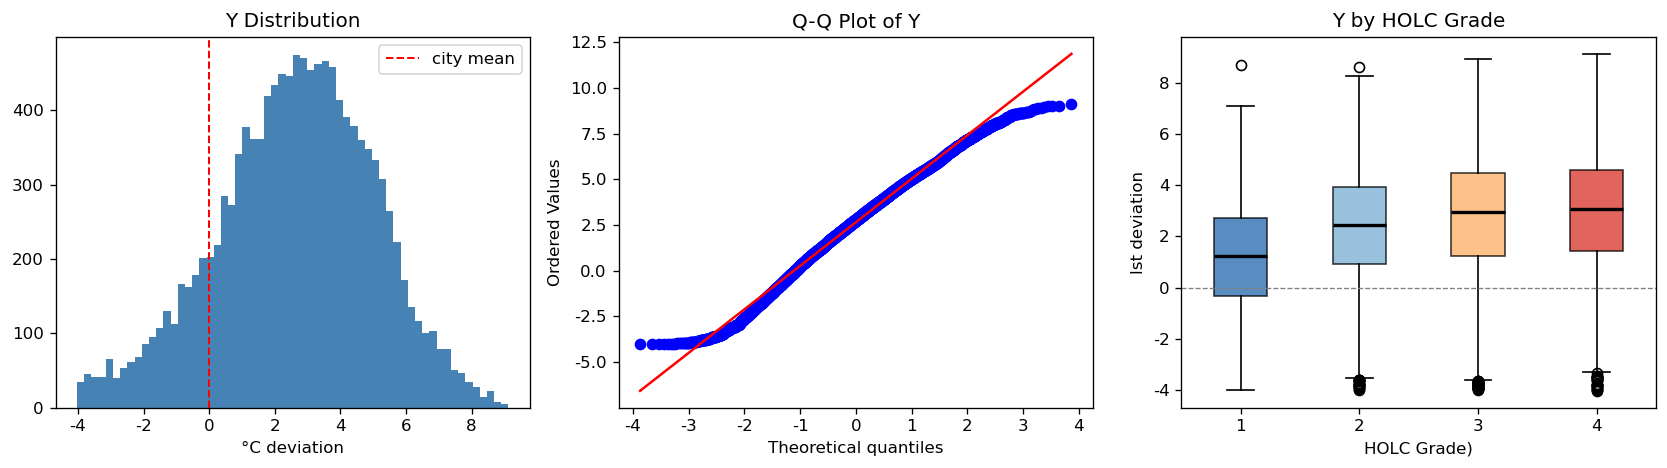

In [14]:
## 이상치 제거 o
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 히스토그램
axes[0].hist(numdf['Y'], bins=60, color='steelblue', linewidth=0.3)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2, label='city mean')
axes[0].set_title('Y Distribution')
axes[0].set_xlabel('°C deviation')
axes[0].legend()

# Q-Q plot
from scipy.stats import probplot
probplot(numdf['Y'], plot=axes[1])
axes[1].set_title('Q-Q Plot of Y')

# HOLC별 Y 분포
holc_order = [1,2,3,4]
holc_colors = ['#2166ac', '#74add1', '#fdae61', '#d73027']
groups = [numdf.loc[numdf['holc_num'] == g, 'Y'].dropna() for g in holc_order]
bp = axes[2].boxplot(groups, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], holc_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    
axes[2].set_xticklabels(holc_order)
axes[2].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[2].set_title('Y by HOLC Grade')
axes[2].set_xlabel('HOLC Grade)')
axes[2].set_ylabel('lst deviation')

plt.tight_layout()
plt.show()

In [15]:
nvars = [] 
non_nvars = [] 

for col in numdf.columns:
    stat, p_value = stats.shapiro(numdf[col].dropna())
    if p_value > 0.05:
        print(col)
        nvars.append(col)
    else:
        non_nvars.append(col)
print(f"정규성을 만족하는 변수의 수: {len(nvars)}개")

정규성을 만족하는 변수의 수: 0개


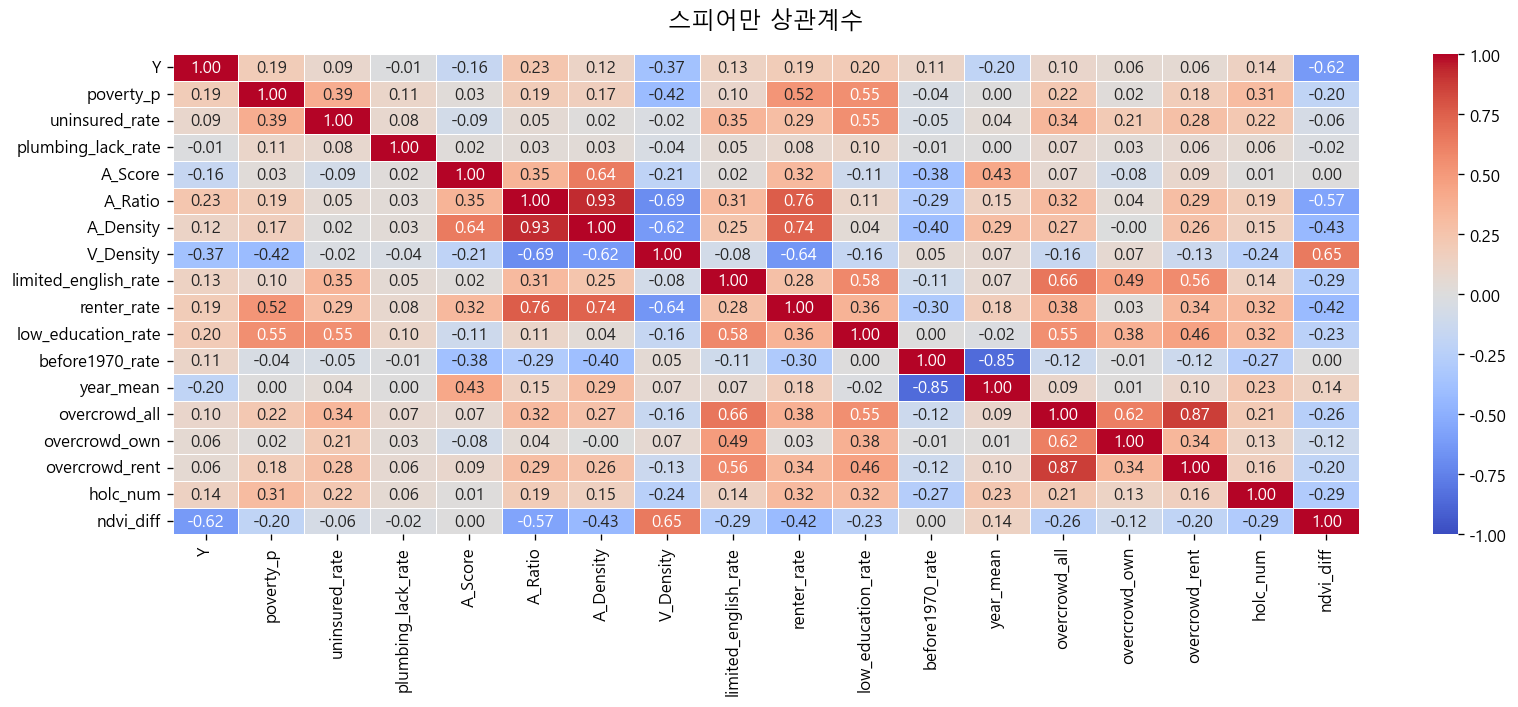

In [16]:
cols = list(numdf.columns)
cols.remove('key')
cols.remove('Y')
cols = ['Y'] + cols

spearman_table = numdf[cols].corr(method='spearman')

plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False 

fig, axes = plt.subplots(figsize=(14, 6))
sns.heatmap(spearman_table, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            linewidths=0.5)
axes.set_title('스피어만 상관계수', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

### 파생변수 생성

In [29]:
# 파생변수 생성1
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
num_p = numdf.copy()
#사회취약성 파생변수
so = [
    'low_education_rate', 
    'renter_rate', 
    'overcrowd_all'
]
so_df = num_p[so]

#표쥰화
sca = StandardScaler()
scaled = sca.fit_transform(so_df)

# pca
pca = PCA(n_components=1)
so_score = pca.fit_transform(scaled)

# 파생변수로 결합
num_p.loc[so_df.index, 'social'] = so_score.flatten()

# 설명력
print(f"제 1주성분 설명비율 : {pca.explained_variance_ratio_[0]:.4f}")
for col, weight in zip(so, pca.components_[0]):
    print(f"{col}: {weight:.4f}")

제 1주성분 설명비율 : 0.6289
low_education_rate: 0.6110
renter_rate: 0.4971
overcrowd_all: 0.6161


In [30]:
#파생변수 생성 2
min_ndvi = num_p['ndvi_diff'].min()
max_ndvi = num_p['ndvi_diff'].max()

num_p['ndvi_vul'] = 1 - ((num_p['ndvi_diff'] - min_ndvi) / (max_ndvi - min_ndvi))

num_p['ndvi_holc'] = num_p['holc_num'] * num_p['ndvi_vul']

corr1, _ = stats.spearmanr(num_p['ndvi_holc'],num_p['Y'])
print(f"환경적 레드라이닝 지수와 lst의 상관계수 : {corr1:.5f}")

환경적 레드라이닝 지수와 lst의 상관계수 : 0.52061


In [31]:
min_ratio = num_p['A_Density'].min()
max_ratio = num_p['A_Density'].max()
num_p['A_Density_scaled'] = (num_p['A_Density'] - min_ratio) / (max_ratio - min_ratio)

num_p['gray'] = num_p['A_Density_scaled'] * num_p['ndvi_vul']
corr2, _ = stats.spearmanr(num_p['gray'], num_p['Y'])
print(f"녹색지수*용적률과 lst의 상관계수 : {corr2:.2f}")

녹색지수*용적률과 lst의 상관계수 : 0.29


In [32]:
num_p.drop(columns=['ndvi_vul', 'A_Density_scaled'], inplace=True)

In [33]:
print(list(num_p.columns))

['key', 'poverty_p', 'uninsured_rate', 'plumbing_lack_rate', 'A_Score', 'A_Ratio', 'A_Density', 'V_Density', 'limited_english_rate', 'renter_rate', 'low_education_rate', 'before1970_rate', 'year_mean', 'overcrowd_all', 'overcrowd_own', 'overcrowd_rent', 'holc_num', 'Y', 'ndvi_diff', 'social', 'ndvi_holc', 'gray']


In [34]:
import pickle
with open('num_p.pickle', 'wb') as pickle_filename:
    pickle.dump(num_p, pickle_filename)

### Spearman 상관계수

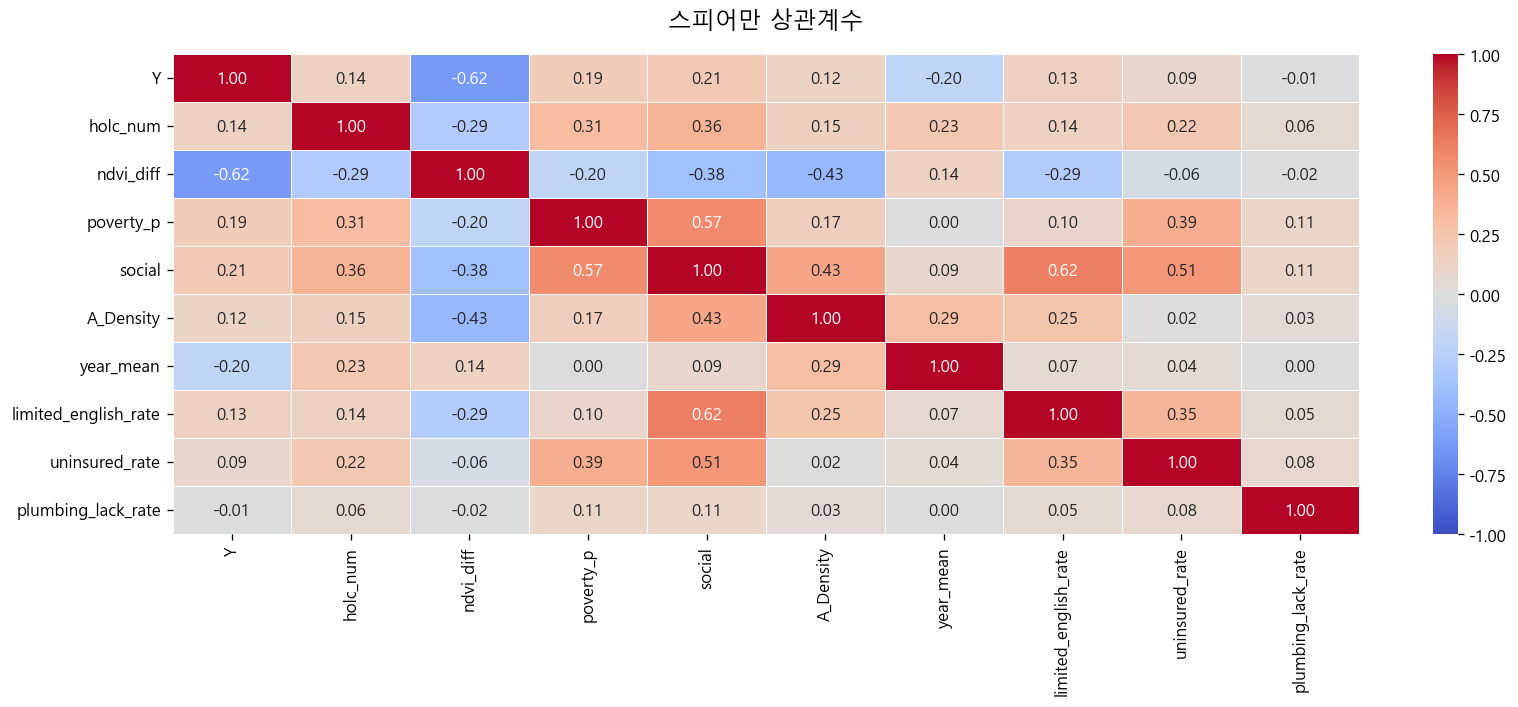

In [35]:
num_new = num_p[['Y', 'holc_num', 'ndvi_diff', 'poverty_p', 'social', 'A_Density', 'year_mean', 'limited_english_rate', 'uninsured_rate', 'plumbing_lack_rate']]
spear_table = num_new.corr(method='spearman')
fig, axes = plt.subplots(figsize=(14, 6))
sns.heatmap(spear_table, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            linewidths=0.5)
axes.set_title('스피어만 상관계수', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

In [37]:
import pandas as pd
from scipy import stats

a = num_p[num_p['holc_num'] == 1]['Y']
b = num_p[num_p['holc_num'] == 2]['Y']
c = num_p[num_p['holc_num'] == 3]['Y']
d = num_p[num_p['holc_num'] == 4]['Y']

kw_stat, kw_p = stats.kruskal(a, b, c, d)

print(f"통계량(Statistic): {kw_stat:.4f}")
print(f"p-value: {kw_p:.5e}")

통계량(Statistic): 409.3615
p-value: 2.07648e-88


In [38]:
# 사후검정 (bonferroni 보정)
c = 6
p_AB = min(stats.mannwhitneyu(a, b).pvalue * c, 1.0)
print(f"A vs B : {p_AB:.5f}")

p_AC = min(stats.mannwhitneyu(a, c).pvalue * c, 1.0)
print(f"A vs C : {p_AC:.5f}")

p_AD = min(stats.mannwhitneyu(a, d).pvalue * c, 1.0)
print(f"A vs D : {p_AD:.5f}")

p_BC = min(stats.mannwhitneyu(b, c).pvalue * c, 1.0)
print(f"B vs C : {p_BC:.5f}")

p_BD = min(stats.mannwhitneyu(b, d).pvalue * c, 1.0)
print(f"B vs D : {p_BD:.5f}")

p_CD = min(stats.mannwhitneyu(c, d).pvalue * c, 1.0)
print(f"C vs D : {p_CD:.5f}")

A vs B : 0.00000
A vs C : 0.60564
A vs D : 0.00000
B vs C : 0.68924
B vs D : 0.00000
C vs D : 0.97690


### 다중회귀분석

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
df_ols =  num_p[['Y', 'holc_num', 'ndvi_diff', 'poverty_p', 'A_Density', 'limited_english_rate', 'uninsured_rate', 'plumbing_lack_rate']].copy()
x_f = list(df_ols.columns)
if 'Y' in x_f:
    x_f.remove('Y')
if 'key' in x_f:
    x_f.remove('key')

In [40]:
y = df_ols['Y']
sel = []
remain = list(x_f)
records = []
step = 1

while remain:
    best_r2 = -1
    best_feat = None
    best_mod = None
    
    for feat in remain:
        X = df_ols[sel + [feat]]
        model = sm.OLS(y, sm.add_constant(X)).fit()
        
        if model.rsquared > best_r2:
            best_r2 = model.rsquared
            best_feat = feat
            best_mod = model

    if step > 1 and (best_r2 - records[-1]['R2']) < 0.0005:
        break
        
    sel.append(best_feat)
    remain.remove(best_feat)
    
    vif = variance_inflation_factor(df_ols[sel].values, sel.index(best_feat)) if len(sel) > 1 else 1.0
    p_val = best_mod.pvalues[best_feat]
    r2_inc = best_r2 - records[-1]['R2'] if step > 1 else best_r2
    
    records.append({'Feature': best_feat, 'R2': best_r2, 'P-value': p_val, 'VIF': vif})

print(pd.DataFrame(records).to_string(index=False, formatters={
    'R2': '{:.4f}'.format, 'R2_Inc': '{:.4f}'.format, 'P-value': '{:.5f}'.format, 'VIF': '{:.2f}'.format
}))

             Feature     R2 P-value  VIF
           ndvi_diff 0.3115 0.00000 1.00
           A_Density 0.3591 0.00000 2.28
           poverty_p 0.3746 0.00000 1.98
            holc_num 0.3760 0.00000 4.61
      uninsured_rate 0.3770 0.00001 2.58
limited_english_rate 0.3788 0.00000 2.50
  plumbing_lack_rate 0.3790 0.05147 1.15


In [41]:
feature_cols = ['holc_num', 'ndvi_diff', 'poverty_p', 'A_Density', 'limited_english_rate', 'uninsured_rate']

X = df_ols[feature_cols]
y = df_ols['Y']

# 상수항
X_with_constant = sm.add_constant(X)

model = sm.OLS(y, X_with_constant).fit()

vif_data = pd.DataFrame()
vif_data["variable"] = X.columns
vif_data["vif"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(model.summary())
print(vif_data.to_string(index=False))

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     1286.
Date:                Sat, 30 May 2026   Prob (F-statistic):               0.00
Time:                        15:56:07   Log-Likelihood:                -25972.
No. Observations:               12663   AIC:                         5.196e+04
Df Residuals:                   12656   BIC:                         5.201e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.5631 

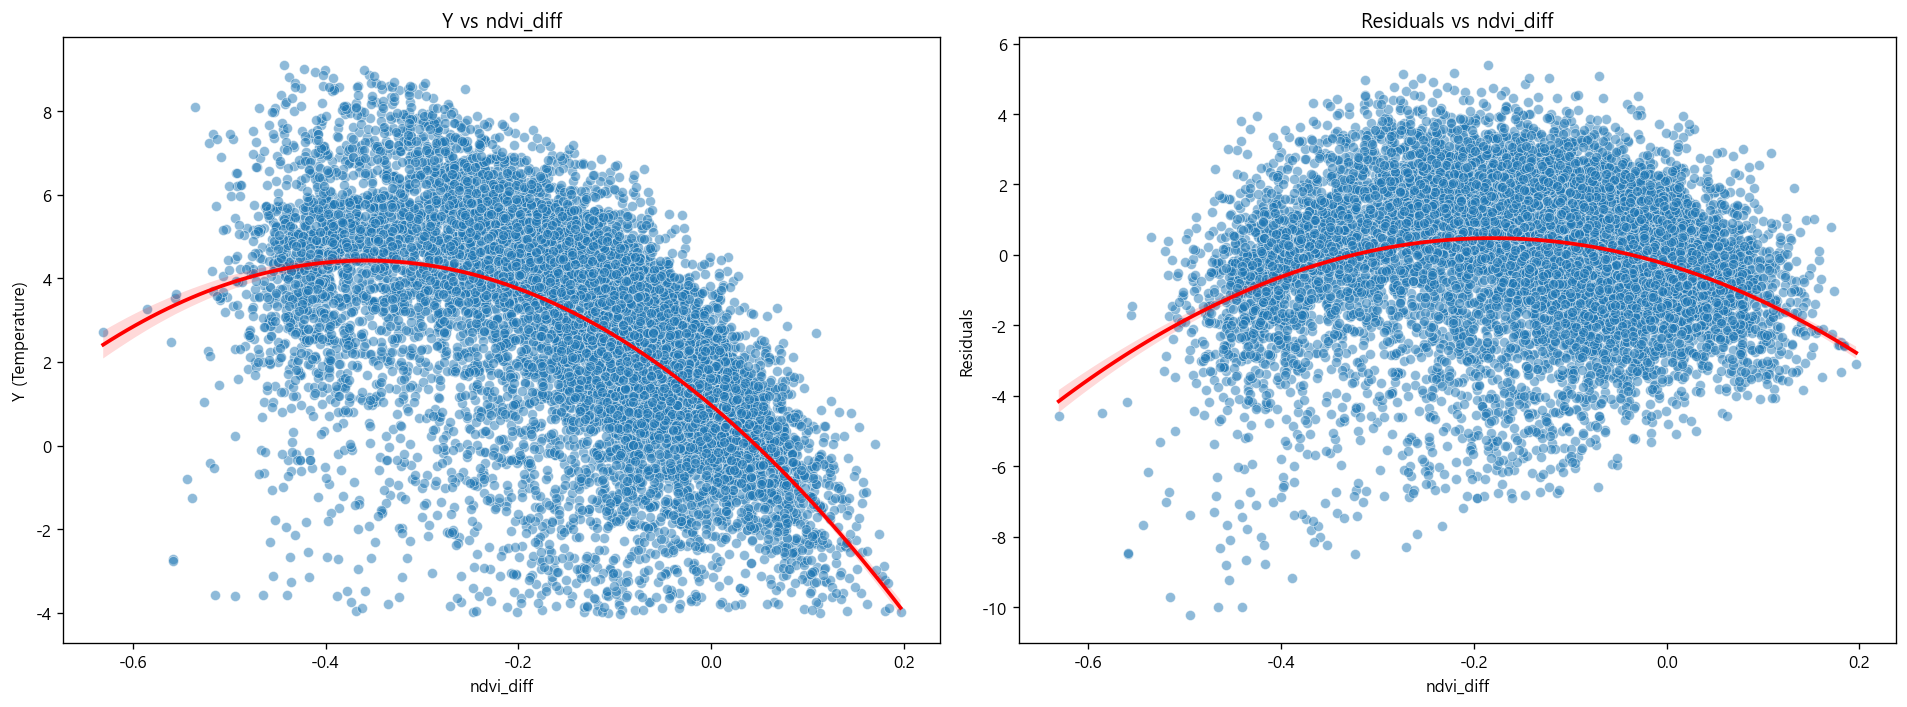

In [42]:
features = ['ndvi_diff', 'A_Density', 'poverty_p', 'holc_num', 'limited_english_rate', 'uninsured_rate']
X = sm.add_constant(df_ols[features])
y = df_ols['Y']
model = sm.OLS(y, X).fit()
df_ols['residuals'] = model.resid

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_ols, x='ndvi_diff', y='Y', alpha=0.5, ax=axes[0])
sns.regplot(data=df_ols, x='ndvi_diff', y='Y', scatter=False, order=2, color='red', ax=axes[0])
axes[0].set_title('Y vs ndvi_diff')
axes[0].set_ylabel('Y (Temperature)')

sns.scatterplot(data=df_ols, x='ndvi_diff', y='residuals', alpha=0.5, ax=axes[1])
sns.regplot(data=df_ols, x='ndvi_diff', y='residuals', scatter=False, order=2, color='red', ax=axes[1])
axes[1].set_title('Residuals vs ndvi_diff')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

### 비선형 고려

In [43]:
df_poly = num_p.copy()
df_poly['ndvi_diff_sq'] = df_poly['ndvi_diff'] ** 2

X = ['holc_num', 'ndvi_diff', 'ndvi_diff_sq', 'poverty_p', 'A_Density', 'limited_english_rate', 'uninsured_rate']

X_poly = df_poly[X]
y_poly = df_poly['Y']
poly_model = sm.OLS(y_poly, sm.add_constant(X_poly)).fit()

print(poly_model.summary())

X_vif = df_poly[X]

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data.to_string(index=False, formatters={'VIF': '{:.2f}'.format}))

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.426
Method:                 Least Squares   F-statistic:                     1341.
Date:                Sat, 30 May 2026   Prob (F-statistic):               0.00
Time:                        15:57:24   Log-Likelihood:                -25473.
No. Observations:               12663   AIC:                         5.096e+04
Df Residuals:                   12655   BIC:                         5.102e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.4773 

In [44]:
df_poly = num_p.copy()
df_poly['ndvi_diff_c'] = df_poly['ndvi_diff'] - df_poly['ndvi_diff'].mean()
df_poly['ndvi_diff_sq'] = df_poly['ndvi_diff_c'] ** 2

X = ['holc_num', 'ndvi_diff_c', 'ndvi_diff_sq', 'poverty_p', 'A_Density', 'limited_english_rate', 'uninsured_rate']

X_poly = df_poly[X]
y_poly = df_poly['Y']
poly_model = sm.OLS(y_poly, sm.add_constant(X_poly)).fit()

print(poly_model.summary())

X_vif = df_poly[X]

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data.to_string(index=False, formatters={'VIF': '{:.2f}'.format}))

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.426
Method:                 Least Squares   F-statistic:                     1341.
Date:                Sat, 30 May 2026   Prob (F-statistic):               0.00
Time:                        15:58:03   Log-Likelihood:                -25473.
No. Observations:               12663   AIC:                         5.096e+04
Df Residuals:                   12655   BIC:                         5.102e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    3.8781 

In [45]:
import pickle
with open('df_ols.pickle', 'wb') as pickle_filename:
    pickle.dump(df_ols, pickle_filename)

In [46]:
import pickle
with open('df_poly.pickle', 'wb') as pickle_filename:
    pickle.dump(df_poly, pickle_filename)

임계점 (ndvi_diff_c 단위)   : -0.2820 :중심화 임계점 예측값
임계점 (ndvi_diff 원래 단위): -0.4237 : 실제 임계점 예측값


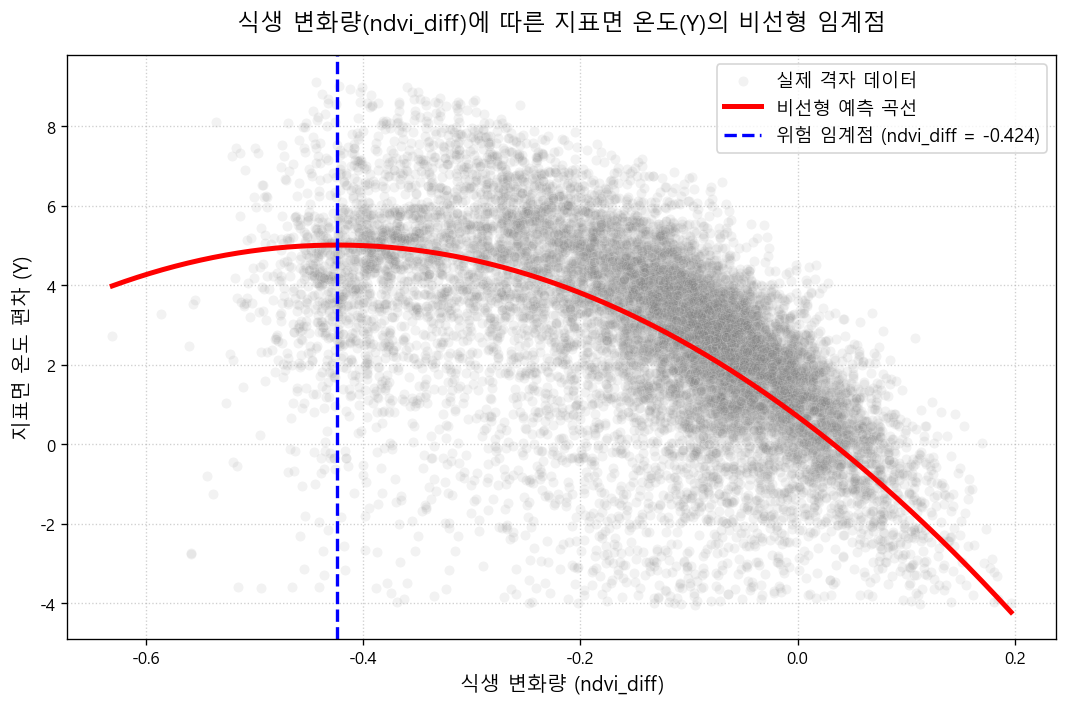

In [47]:
b1 = poly_model.params['ndvi_diff_c']
b2 = poly_model.params['ndvi_diff_sq']
mean_ndvi = df_poly['ndvi_diff'].mean()
X_features = ['holc_num', 'ndvi_diff_c', 'ndvi_diff_sq',
              'poverty_p', 'A_Density',
              'limited_english_rate', 'uninsured_rate']

threshold_c    = -b1 / (2 * b2)                  # ndvi_diff_c 단위 (계산용)
threshold_orig = threshold_c + mean_ndvi          # ndvi_diff 원래 단위 (보고서 기재값)

print(f"임계점 (ndvi_diff_c 단위)   : {threshold_c:.4f} :중심화 임계점 예측값")
print(f"임계점 (ndvi_diff 원래 단위): {threshold_orig:.4f} : 실제 임계점 예측값")

# ── 시각화 ────────────────────────────────────────────────────
# 나머지 변수는 평균 고정, ndvi_diff 범위에서 순수 효과 곡선 추출
fixed = {v: df_poly[v].mean() for v in X_features
         if v not in ('ndvi_diff_c', 'ndvi_diff_sq')}

x_orig  = np.linspace(df_poly['ndvi_diff'].min(),
                      df_poly['ndvi_diff'].max(), 500)
x_c     = x_orig - mean_ndvi          # 곡선 계산에는 중심화값 사용
y_curve = (
    poly_model.params['const']
    + b1 * x_c
    + b2 * x_c ** 2
    + sum(poly_model.params[v] * fixed[v] for v in fixed)
)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_poly, x='ndvi_diff', y='Y',
                alpha=0.1, color='gray', label='실제 격자 데이터')
plt.plot(x_orig, y_curve, color='red', linewidth=3, label='비선형 예측 곡선')
plt.axvline(threshold_orig, color='blue', linestyle='--', linewidth=2,
            label=f'위험 임계점 (ndvi_diff = {threshold_orig:.3f})')

plt.title('식생 변화량(ndvi_diff)에 따른 지표면 온도(Y)의 비선형 임계점',
          fontsize=14, pad=15)
plt.xlabel('식생 변화량 (ndvi_diff)', fontsize=12)
plt.ylabel('지표면 온도 편차 (Y)', fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 머신러닝

In [48]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

In [53]:
name_col = df_drop[['key', 'name']] 
df_ma = df_poly.copy().merge(name_col, on='key', how='left')
print(list(df_ma.columns))

['key', 'poverty_p', 'uninsured_rate', 'plumbing_lack_rate', 'A_Score', 'A_Ratio', 'A_Density', 'V_Density', 'limited_english_rate', 'renter_rate', 'low_education_rate', 'before1970_rate', 'year_mean', 'overcrowd_all', 'overcrowd_own', 'overcrowd_rent', 'holc_num', 'Y', 'ndvi_diff', 'social', 'ndvi_holc', 'gray', 'ndvi_diff_c', 'ndvi_diff_sq', 'name']


In [55]:
features = ['ndvi_diff', 'A_Density', 'poverty_p', 'holc_num', 'limited_english_rate', 'uninsured_rate']
X = df_ma[features].copy()
y = df_ma['Y'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Group K-Fold (공간누수 방지)
groups = df_ma['name']
gkf    = GroupKFold(n_splits=5)

# RandomizedSearchCV
rand_results = {}

xgb_rand = RandomizedSearchCV(
    XGBRegressor(random_state=1, eval_metric='rmse'),
    param_distributions={
        'learning_rate': stats.uniform(0.01, 0.2),
        'max_depth':     [3, 5, 7, 10],
        'n_estimators':  [100, 500, 1000]
    },
    n_iter=10, cv=5, scoring='r2', n_jobs=1, random_state=1
)
xgb_rand.fit(X_train, y_train)
rand_results['XGBoost'] = xgb_rand.best_params_

lgb_rand = RandomizedSearchCV(
    LGBMRegressor(random_state=1, verbosity=-1),
    param_distributions={
        'learning_rate': stats.uniform(0.01, 0.2),
        'max_depth':     [3, 5, 7, 10],
        'n_estimators':  [100, 500, 1000]
    },
    n_iter=10, cv=5, scoring='r2', n_jobs=1, random_state=1
)
lgb_rand.fit(X_train, y_train)
rand_results['LightGBM'] = lgb_rand.best_params_

# GridSearchCV
models_grid_space = {
    'RandomForest': (
        RandomForestRegressor(random_state=1),
        {'n_estimators': [50, 100, 200],
         'max_depth':    [5, 10, None],
         'max_features': [0.5, 'sqrt']}
    ),
    'ExtraTrees': (
        ExtraTreesRegressor(random_state=1),
        {'n_estimators': [50, 100, 200],
         'max_depth':    [5, 10, None],
         'max_features': [0.2, 0.5]}
    ),
    'GradientBoosting': (
        GradientBoostingRegressor(random_state=1),
        {'learning_rate': [0.01, 0.05, 0.1],
         'n_estimators':  [100, 500],
         'max_depth':     [3, 5]}
    ),
    'XGBoost': (
        XGBRegressor(random_state=1, eval_metric='rmse'),
        {
            'learning_rate': [
                max(0.01, rand_results['XGBoost']['learning_rate'] - 0.03),
                rand_results['XGBoost']['learning_rate'],
                rand_results['XGBoost']['learning_rate'] + 0.03
            ],
            'max_depth': [
                max(3, rand_results['XGBoost']['max_depth'] - 2),
                rand_results['XGBoost']['max_depth'],
                rand_results['XGBoost']['max_depth'] + 2
            ],
            'n_estimators': [rand_results['XGBoost']['n_estimators']]
        }
    ),
    'LightGBM': (
        LGBMRegressor(random_state=1, verbosity=-1),
        {
            'learning_rate': [
                max(0.01, rand_results['LightGBM']['learning_rate'] - 0.03),
                rand_results['LightGBM']['learning_rate'],
                rand_results['LightGBM']['learning_rate'] + 0.03
            ],
            'max_depth': [
                max(3, rand_results['LightGBM']['max_depth'] - 2),
                rand_results['LightGBM']['max_depth'],
                rand_results['LightGBM']['max_depth'] + 2
            ],
            'n_estimators': [rand_results['LightGBM']['n_estimators']]
        }
    )
}

           Model Test_R2 Test_RMSE GKF_R2_mean GKF_R2_std GKF_RMSE
    RandomForest  0.4773    1.7367      0.3074     0.0694   1.8704
      ExtraTrees  0.4784    1.7348      0.2776     0.0842   1.9085
GradientBoosting  0.4755    1.7397      0.2986     0.0736   1.8834
         XGBoost  0.4762    1.7385      0.2918     0.0859   1.8908
        LightGBM  0.4766    1.7378      0.2947     0.0925   1.8852


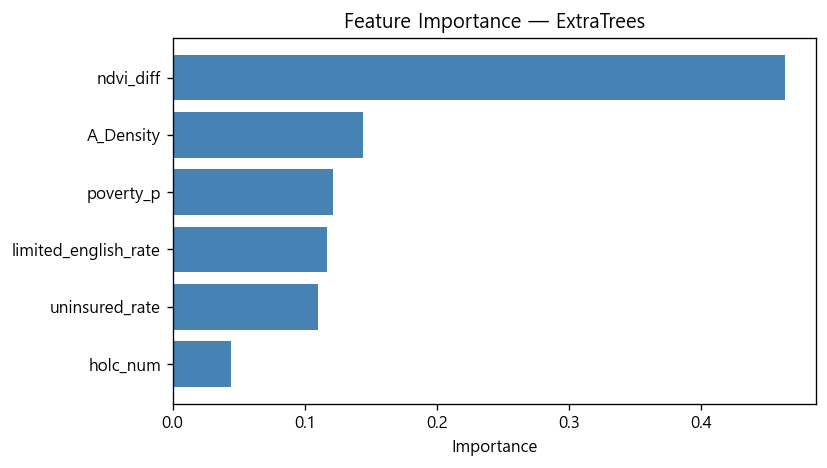

In [56]:
# 모델별 평가 
final_metrics = []
best_estimators = {}   # 변수 중요도 추출용

for name, (model, grid_space) in models_grid_space.items():

    # GridSearchCV로 하이퍼파라미터 
    grid_search = GridSearchCV(
        model, param_grid=grid_space,
        cv=5, scoring='r2', n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    best_mod = grid_search.best_estimator_
    best_estimators[name] = best_mod

    # Train-Test 성능
    preds  = best_mod.predict(X_test)
    r2     = r2_score(y_test, preds)
    rmse   = np.sqrt(mean_squared_error(y_test, preds))

    # Group K-Fold 성능 
    gkf_r2, gkf_rmse = [], []
    for tr_idx, te_idx in gkf.split(X, y, groups):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        # best params 재학습
        fold_mod = grid_search.best_estimator_.__class__(
            **grid_search.best_params_
        )
        fold_mod.fit(X_tr, y_tr)
        fold_pred = fold_mod.predict(X_te)
        gkf_r2.append(r2_score(y_te, fold_pred))
        gkf_rmse.append(np.sqrt(mean_squared_error(y_te, fold_pred)))

    final_metrics.append({
        'Model':        name,
        'Test_R2':      r2,
        'Test_RMSE':    rmse,
        'GKF_R2_mean':  np.mean(gkf_r2),
        'GKF_R2_std':   np.std(gkf_r2),
        'GKF_RMSE':     np.mean(gkf_rmse),
        'Best_Params':  grid_search.best_params_
    })

# 성능 테이블 출력
df_report = pd.DataFrame(final_metrics)
print(df_report[['Model', 'Test_R2', 'Test_RMSE',
                 'GKF_R2_mean', 'GKF_R2_std', 'GKF_RMSE']].to_string(
    index=False,
    formatters={
        'Test_R2':     '{:.4f}'.format,
        'Test_RMSE':   '{:.4f}'.format,
        'GKF_R2_mean': '{:.4f}'.format,
        'GKF_R2_std':  '{:.4f}'.format,
        'GKF_RMSE':    '{:.4f}'.format,
    }
))


# 최고 성능 모델 변수 중요도
best_name = df_report.loc[df_report['Test_R2'].idxmax(), 'Model']
best_fi   = best_estimators[best_name].feature_importances_

fi_df = (pd.DataFrame({'Feature': features, 'Importance': best_fi})
           .sort_values('Importance', ascending=True))

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
ax.set_title(f'Feature Importance — {best_name}')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [71]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ── 앙상블 대상 모델 리스트 ──────────────────────────────────
ensemble_names  = ['RandomForest', 'ExtraTrees', 'GradientBoosting', 'XGBoost', 'LightGBM']
ensemble_models = [best_estimators[n] for n in ensemble_names]

# ── 소프트 보팅 가중치: Test_R2 기준 정규화 ──────────────────
r2_vals = np.array([df_report.set_index('Model').loc[n, 'Test_R2'] for n in ensemble_names])
soft_weights = r2_vals / r2_vals.sum()
print('소프트 보팅 가중치:')
for n, w in zip(ensemble_names, soft_weights):
    print(f'  {n:<20s}: {w:.4f}')

# ── Test set 예측 ─────────────────────────────────────────────
preds_test = np.column_stack([m.predict(X_test) for m in ensemble_models])

# Hard Voting: 단순 평균
hard_pred_test  = preds_test.mean(axis=1)
hard_r2_test    = r2_score(y_test, hard_pred_test)
hard_rmse_test  = np.sqrt(mean_squared_error(y_test, hard_pred_test))

# Soft Voting: 가중 평균
soft_pred_test  = preds_test @ soft_weights
soft_r2_test    = r2_score(y_test, soft_pred_test)
soft_rmse_test  = np.sqrt(mean_squared_error(y_test, soft_pred_test))

print(f'\n[Hard Voting]  Test R²={hard_r2_test:.4f}  RMSE={hard_rmse_test:.4f}')
print(f'[Soft Voting]  Test R²={soft_r2_test:.4f}  RMSE={soft_rmse_test:.4f}')

소프트 보팅 가중치:
  RandomForest        : 0.2002
  ExtraTrees          : 0.2007
  GradientBoosting    : 0.1995
  XGBoost             : 0.1997
  LightGBM            : 0.1999

[Hard Voting]  Test R²=0.4846  RMSE=1.7245
[Soft Voting]  Test R²=0.4846  RMSE=1.7245


In [70]:
import pickle
with open('df_ma.pickle', 'wb') as pickle_filename:
    pickle.dump(df_ma, pickle_filename)

In [67]:
# !pip install causalml dowhy
# HOLC → ndvi_diff(매개) → Y

df_cau = df_poly[['holc_num', 'ndvi_diff', 'Y', 'A_Density', 'poverty_p',  'limited_english_rate', 'uninsured_rate']].copy()

#1
m1 = sm.OLS(df_cau['Y'],
            sm.add_constant(df_cau[['holc_num']])).fit()
c_total = m1.params['holc_num']
print(f'[Step 1] 총효과  holc_num > Y: β={c_total:.4f}, p={m1.pvalues["holc_num"]:.4e}')

#2
m2 = sm.OLS(df_cau['ndvi_diff'],
            sm.add_constant(df_cau[['holc_num']])).fit()
a_coef = m2.params['holc_num']
print(f'[Step 2] holc_num > ndvi_diff: β={a_coef:.4f}, p={m2.pvalues["holc_num"]:.4e}')

#3
m3 = sm.OLS(df_cau['Y'],
            sm.add_constant(df_cau[['holc_num', 'ndvi_diff']])).fit()
b_coef  = m3.params['ndvi_diff']
c_prime = m3.params['holc_num']
print(f'[Step 3] ndvi_diff > Y (M 통제 후): β={b_coef:.4f}, p={m3.pvalues["ndvi_diff"]:.4e}')
print(f'[Step 3] holc_num 직접효과:          β={c_prime:.4f}, p={m3.pvalues["holc_num"]:.4e}')

# Sobel Test
a, b   = a_coef, b_coef
se_a   = m2.bse['holc_num']
se_b   = m3.bse['ndvi_diff']
indirect = a * b
sobel_se = np.sqrt(b**2 * se_a**2 + a**2 * se_b**2)
z_sobel  = indirect / sobel_se
p_sobel  = 2 * (1 - stats.norm.cdf(abs(z_sobel)))

print(f'\n[Sobel Test]')
print(f'  간접효과 (a×b)  = {indirect:.4f}')
print(f'  Sobel Z         = {z_sobel:.4f}')
print(f'  p-value         = {p_sobel:.4e}')
print(f'  매개 비율       = {indirect / c_total * 100:.1f}%')

if abs(c_prime) < abs(c_total) and p_sobel < 0.05:
    print('\n 부분 매개 (partial mediation)')
    if m3.pvalues['holc_num'] > 0.05:
        print(' 완전 매개 (full mediation)')

[Step 1] 총효과  holc_num > Y: β=0.4471, p=4.1670e-73
[Step 2] holc_num > ndvi_diff: β=-0.0484, p=6.7933e-256
[Step 3] ndvi_diff > Y (M 통제 후): β=-9.6223, p=0.0000e+00
[Step 3] holc_num 직접효과:          β=-0.0183, p=3.9805e-01

[Sobel Test]
  간접효과 (a×b)  = 0.4654
  Sobel Z         = 31.5017
  p-value         = 0.0000e+00
  매개 비율       = 104.1%

 부분 매개 (partial mediation)
 완전 매개 (full mediation)


Bootstrap 95% CI: [0.4360, 0.4958]


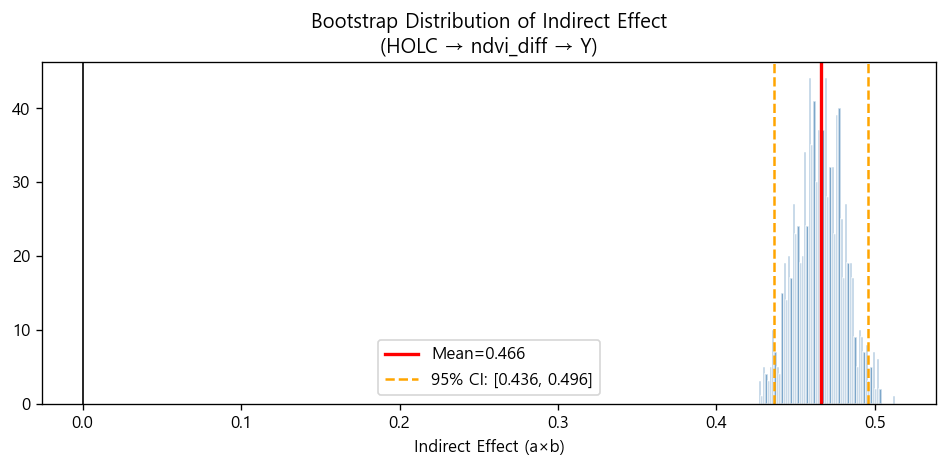

In [68]:
# Bootstrap 신뢰구간
np.random.seed(42)
N_BOOT = 1000
boot_indirect = []

for _ in range(N_BOOT):
    sample = df_cau.sample(frac=1, replace=True)
    try:
        b_m2 = sm.OLS(sample['ndvi_diff'],
                      sm.add_constant(sample[['holc_num']])).fit().params['holc_num']
        b_m3 = sm.OLS(sample['Y'],
                      sm.add_constant(sample[['holc_num', 'ndvi_diff']])).fit().params['ndvi_diff']
        boot_indirect.append(b_m2 * b_m3)
    except:
        continue

ci_low  = np.percentile(boot_indirect, 2.5)
ci_high = np.percentile(boot_indirect, 97.5)
print(f'Bootstrap 95% CI: [{ci_low:.4f}, {ci_high:.4f}]')

# 시각화
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_indirect, bins=60, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(np.mean(boot_indirect), color='red', linewidth=2, label=f'Mean={np.mean(boot_indirect):.3f}')
ax.axvline(ci_low,  color='orange', linestyle='--', linewidth=1.5, label=f'95% CI: [{ci_low:.3f}, {ci_high:.3f}]')
ax.axvline(ci_high, color='orange', linestyle='--', linewidth=1.5)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Bootstrap Distribution of Indirect Effect\n(HOLC → ndvi_diff → Y)', fontsize=12)
ax.set_xlabel('Indirect Effect (a×b)')
ax.legend()
plt.tight_layout()
plt.savefig('mediation_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
df_auc = df_auc.copy()
confounders = ['poverty_p', 'A_Density', 'ndvi_diff',  'limited_english_rate', 'uninsured_rate' ]

df_auc = df_auc[df_auc['holc_num'].isin([1, 4])].copy()   # A=1, D=4
df_auc['treated'] = (df_auc['holc_num'] == 4).astype(int)
df_auc = df_auc[['treated', 'Y'] + confounders].dropna().copy()

# 성향점수 추정
scaler = StandardScaler()
X_ps = scaler.fit_transform(df_auc[confounders])
lr = LogisticRegression(max_iter=1000)
lr.fit(X_ps, df_auc['treated'])
df_auc['ps'] = lr.predict_proba(X_ps)[:, 1]

print(f'처치군(D등급): {df_auc["treated"].sum():,}개')
print(f'대조군(A등급): {(df_auc["treated"]==0).sum():,}개')
print(f'성향점수 분리 가능성 (AUC): ', end='')
from sklearn.metrics import roc_auc_score
print(f'{roc_auc_score(df_auc["treated"], df_auc["ps"]):.3f}')

# Nearest Neighbor Matching (caliper=0.05)
treated   = df_auc[df_auc['treated'] == 1].copy()
control   = df_auc[df_auc['treated'] == 0].copy()
CALIPER   = 0.05

matched_pairs = []
used_ctrl = set()

for i, t_row in treated.iterrows():
    diffs = (control['ps'] - t_row['ps']).abs()
    diffs = diffs[~diffs.index.isin(used_ctrl)]
    if diffs.empty:
        continue
    best_idx = diffs.idxmin()
    if diffs[best_idx] <= CALIPER:
        matched_pairs.append({'treat_Y': t_row['Y'],
                               'ctrl_Y' : control.loc[best_idx, 'Y']})
        used_ctrl.add(best_idx)

처치군(D등급): 3,490개
대조군(A등급): 792개
성향점수 분리 가능성 (AUC): 0.903
